In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras

In [12]:
from keras.models import Sequential, Model
from keras.layers import (
    Dense, Input, ReLU, Flatten, Rescaling, Convolution2D
    , Reshape, MaxPooling2D
)
from keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
from keras.metrics import Accuracy
from keras.optimizers import Adam

from keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=1)
print(f'{x_train.shape} - {x_val.shape}')

(48000, 28, 28) - (12000, 28, 28)


In [11]:
print(233/255)
print(233*(1/255))

0.9137254901960784
0.9137254901960784


In [25]:
def build_cnn_model() -> Sequential:
    model = Sequential([
        Input((28, 28))
        , Reshape((28, 28, 1))
        , Rescaling(1./255)

        , Convolution2D(
            filters=32, kernel_size=(2, 2), activation='relu'
            , strides=(1, 1), padding='same'
            )
        , Convolution2D(32, 2, 1, 'same', activation='relu')
        , MaxPooling2D((2, 2))

        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , MaxPooling2D((2, 2))

        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , MaxPooling2D((2, 2))

        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , MaxPooling2D((2, 2))

        , Flatten()
        , Dense(128, activation='relu')
        , Dense(10, activation='softmax')

    ])

    model.compile(
        optimizer=Adam(), loss=SparseCategoricalCrossentropy
        , metrics=['accuracy']
        )

    return model

cnn = build_cnn_model()
cnn.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_10 (Reshape)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 28, 28, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 28, 28, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 14, 14, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 7, 7, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 7, 7, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 3, 3, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 3, 3, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,394 (407.79 KB)

 Trainable params: 104,394 (407.79 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
cnn.fit(x_train, y_train, batch_size=512
        , epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9912 - loss: 0.0268 - val_accuracy: 0.9847 - val_loss: 0.0550
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9939 - loss: 0.0192 - val_accuracy: 0.9833 - val_loss: 0.0622
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9941 - loss: 0.0179 - val_accuracy: 0.9858 - val_loss: 0.0545
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9952 - loss: 0.0152 - val_accuracy: 0.9828 - val_loss: 0.0683
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9947 - loss: 0.0148 - val_accuracy: 0.9845 - val_loss: 0.0608
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9961 - loss: 0.0111 - val_accuracy: 0.9800 - val_loss: 0.0797
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9940 - loss: 0.0161 - val_accuracy: 0.9874 - val_loss: 0.0515
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9956 - loss: 0.0126 - val_accuracy: 0.9836 - v

/tmp/ipykernel_9389/129707683.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(cnn.layers[-1].weights[0]).ravel())


<Axes: ylabel='Density'>

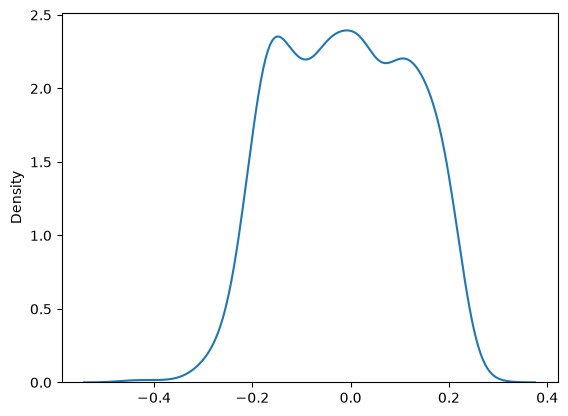

In [38]:
sns.kdeplot(np.array(cnn.layers[-1].weights[0]).ravel())

In [39]:
for idx, layer in enumerate(cnn.layers):
    print(f'{idx} - {layer.name}')

0 - reshape_10
1 - rescaling_10
2 - conv2d_58
3 - conv2d_59
4 - max_pooling2d_29
5 - conv2d_60
6 - conv2d_61
7 - max_pooling2d_30
8 - conv2d_62
9 - conv2d_63
10 - max_pooling2d_31
11 - conv2d_64
12 - conv2d_65
13 - max_pooling2d_32
14 - flatten_10
15 - dense_20
16 - dense_21


In [61]:
# feature maps
f_map_extractor = Model(inputs=cnn.inputs, outputs=[cnn.layers[7].output, cnn.layers[-1].output])
f_map = f_map_extractor.predict(x_test)
f_map



  1/313 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


[array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 2.28086519e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 1.56368279e+00, ...,
           0.00000000e+00, 5.19888687e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 1.50161958e+00, ...,
           0.00000000e+00, 4.96512604e+00, 0.00000000e+00],
          ...,
          [0.00000000e+00, 0.00000000e+00, 1.16681623e+00, ...,
           0.00000000e+00, 3.98269200e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 1.86161175e-01, ...,
           0.00000000e+00, 4.73672807e-01, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
 
         [[2.65757322e-01, 2.16622162e+00, 0.00000000e+00, ...,
           3.25430059e+00, 1.68219519e+00, 0.00000000e+00],
          [1.93301690e+00, 5.57124472e+00, 0.00000000e+00, ...,
           8.36013699e+00, 1.62926137e+00, 0.00000

In [62]:
f_map[-1]

array([[4.81552736e-16, 3.37604701e-11, 2.12550377e-12, ...,
        1.00000000e+00, 2.89594130e-12, 3.63214792e-10],
       [2.78800254e-08, 3.12351500e-09, 9.99999881e-01, ...,
        1.96803923e-12, 6.59151880e-08, 5.06941087e-14],
       [3.06642640e-08, 9.99945760e-01, 1.18144797e-07, ...,
        1.07052492e-05, 3.51006238e-05, 4.04716417e-07],
       ...,
       [1.22384978e-19, 1.00903383e-11, 1.75098432e-20, ...,
        1.49256996e-11, 8.57292275e-12, 1.53784701e-08],
       [1.10870047e-13, 1.75676513e-16, 1.08070433e-13, ...,
        3.29365850e-16, 3.64941731e-03, 1.26755956e-14],
       [1.57910046e-12, 7.58877993e-18, 4.61541937e-13, ...,
        3.58988569e-18, 1.36392651e-11, 7.80753550e-20]],
      shape=(10000, 10), dtype=float32)

In [ ]:
f_map[0][:, :, 0]

array([[0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.06103878],
       [0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.06103878],
       [0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 , 0.1458787 ,
        0.1458787 , 0.1458

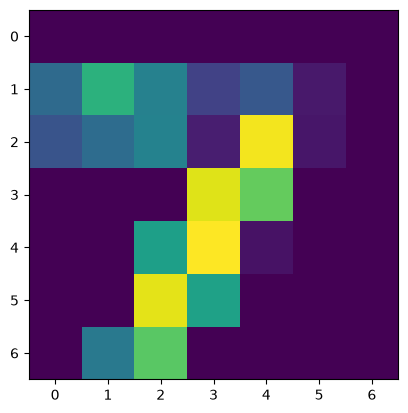

In [59]:
# plt.imshow(x_test[0], cmap='gray')
# plt.show()

plt.imshow(f_map[0][:, :, 48])
plt.show()